In [116]:
import numba as nb
import numpy as np
import matplotlib.pyplot as plt

In [117]:
Lx, Ly, Lz = 2, 2, 2
dx, dy, dz = 1e-1, 1e-1, 1e-1
l1 = 1

T, dt = 10, 1e-3
# alpha1, alpha2 = 1, 1
# kappa1, kappa2 = 1, 1
alpha1, alpha2 = 1, 0.5
kappa1, kappa2 = 1, 0.5

In [118]:
Nx, Ny, Nz = int(Lx / dx), int(Ly / dy), int(Lz / dz)
N1 = int(l1 / dx)
Nt = int(T / dt)

@nb.njit(parallel=True, fastmath=True)
def step(u_0, u_1):
    for x in range(1, N1):
        for y in range(1, Ny - 1):
            for z in range(1, Nz - 1):
                d2udx2 = (u_0[x + 1, y, z] - 2 * u_0[x, y, z] + u_0[x - 1, y, z]) / dx ** 2
                d2udy2 = (u_0[x, y + 1, z] - 2 * u_0[x, y, z] + u_0[x, y - 1, z]) / dy ** 2
                d2udz2 = (u_0[x, y, z + 1] - 2 * u_0[x, y, z] + u_0[x, y, z - 1]) / dz ** 2
                delta_u = d2udx2 + d2udy2 + d2udz2
                u_1[x, y, z] = dt * alpha1 * delta_u + u_0[x, y, z]

    for x in range(N1 + 1, Nx - 1):
        for y in range(1, Ny - 1):
            for z in range(1, Nz - 1):
                d2udx2 = (u_0[x + 1, y, z] - 2 * u_0[x, y, z] + u_0[x - 1, y, z]) / dx ** 2
                d2udy2 = (u_0[x, y + 1, z] - 2 * u_0[x, y, z] + u_0[x, y - 1, z]) / dy ** 2
                d2udz2 = (u_0[x, y, z + 1] - 2 * u_0[x, y, z] + u_0[x, y, z - 1]) / dz ** 2
                delta_u = d2udx2 + d2udy2 + d2udz2
                u_1[x, y, z] = dt * alpha1 * delta_u + u_0[x, y, z]

    for y in range(1, Ny - 1):
        for z in range(1, Nz - 1):
            u_1[N1, y, z] = (kappa1 * u_0[N1 - 1, y, z] + kappa2 * u_0[N1 + 1, y, z]) / (kappa1 + kappa2)


history = []
u_0 = np.zeros((Nx, Ny, Nz), dtype=np.float32)
# u_0[Nx - 1, :, :] = u_0[0, :, :] = np.ones_like(u_0[0, :, :])
# u_0[:, Ny - 1, :] = u_0[:, 0, :] = np.ones_like(u_0[:, 0, :])
# u_0[:, :, Nz - 1] = u_0[:, :, 0] = np.ones_like(u_0[:, :, 0])

u_0[0, :, :] = np.ones_like(u_0[0, :, :])
u_0[:10, Ny - 1, :] = u_0[:10, 0, :] = np.ones_like(u_0[:10, 0, :])
u_0[:10, :, Nz - 1] = u_0[:10, :, 0] = np.ones_like(u_0[:10, :, 0])
u_1 = u_0.copy()

for i in range(1000):
    step(u_0, u_1)
    if i % 20 == 0:
        history.append(u_1.copy())
    u_0, u_1 = u_1, u_0



/home/mtw/Projects/diffeq/.venv/lib/python3.14/site-packages/numba/core/typed_passes.py:338: NumbaPerformanceWarning: 
The keyword argument 'parallel=True' was specified but no transformation for parallel execution was possible.

To find out why, try turning on parallel diagnostics, see https://numba.readthedocs.io/en/stable/user/parallel.html#diagnostics for help.

File "../../../../../tmp/ipykernel_11761/4237516659.py", line 5:
<source missing, REPL/exec in use?>

  warnings.warn(errors.NumbaPerformanceWarning(msg,


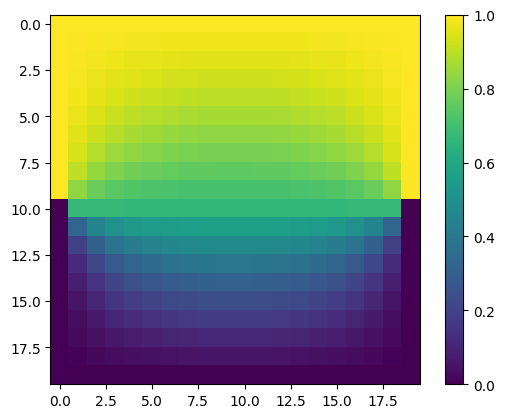

In [119]:
plt.imshow(u_0[:, 10], vmin=0, vmax=1)
plt.colorbar()
plt.show()

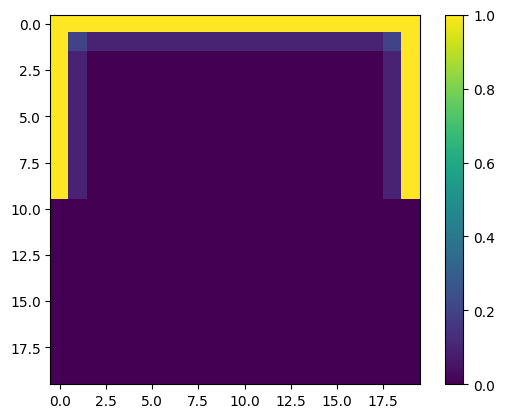

In [120]:
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots()
hm = ax.imshow(history[0][:, 10])
fig.colorbar(hm)


def update(i):
    hm.set_data(history[i][:, 10])
    return hm,

anim = FuncAnimation(fig=fig, func=update, frames=len(history), interval=100, blit=True)
plt.show()
anim.save('out.mp4')
